<a href="https://colab.research.google.com/github/avi-dot-ai/FL-W/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/avi-dot-ai/FL-W/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

**Lane: ranking signal analysis.** This notebook turns the Week-4 transparent Page-1/low-CTR rule into a human-reviewed action queue. It orders inspection; it does not predict future outcomes, diagnose low CTR, prove a refresh helps, or make a publishing decision. Outputs contain no client IDs, URLs, or queries.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*


A candidate needs at least 3,000 trailing-90-day impressions, average position 4–10, and CTR at or below 0.30%. It is ordered by its click gap to a 0.30% reference. That is an exposure-weighted sorting aid, **not** a forecast of clicks or business value. The archetype only routes review: recently updated pages are diagnosed before another refresh; stale pages get a currentness check too.

In [5]:

from pathlib import Path
import platform
import numpy as np
import pandas as pd
import json
import os, sys, subprocess

SEED = 42
TOP_KS = (50, 100)

def show(table):
    print(table.to_string(index=False) if isinstance(table, pd.DataFrame) else table)

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

# Define paths using Path objects, relative to the current working directory (REPO_DIR)
DATA_PATH = Path('data/raw/content_refresh_anonymized.csv')
OUTPUT_DIR = Path('work/outputs')
FIGURE_DIR = Path('work/figures')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MIN_IMPRESSIONS, MIN_POSITION, MAX_POSITION, CTR_REFERENCE_PCT = 3_000, 4, 10, 0.30

df = pd.read_csv(DATA_PATH)
assert df['content_id'].is_unique
eligible = df['impressions_90d'].ge(MIN_IMPRESSIONS) & df['avg_position'].between(MIN_POSITION, MAX_POSITION) & df['ctr'].le(CTR_REFERENCE_PCT)
queue = df.loc[eligible].copy()
queue['reference_click_gap'] = queue['impressions_90d'] * (CTR_REFERENCE_PCT - queue['ctr']) / 100
# Routing labels, not diagnoses or treatment recommendations.
queue['archetype'] = np.select([queue['days_since_last_update'].le(90), queue['days_since_last_update'].ge(181)], ['recently_updated_ctr_gap', 'stale_ctr_gap'], default='mid_cycle_ctr_gap')
ACTION_MAP = {
 'recently_updated_ctr_gap': ('diagnose_serp_snippet_and_intent_before_any_refresh', 'visible_page1_low_ctr__recent_update'),
 'mid_cycle_ctr_gap': ('review_title_snippet_and_search_intent', 'visible_page1_low_ctr__mid_cycle'),
 'stale_ctr_gap': ('review_currentness_then_title_snippet_and_intent', 'visible_page1_low_ctr__stale'),
}
queue[['action_label', 'reason_code']] = queue['archetype'].map(ACTION_MAP).apply(pd.Series)
queue['review_bundle'] = queue['archetype'].map({'recently_updated_ctr_gap': 'Check current SERP and prior update before proposing more changes.', 'mid_cycle_ctr_gap': 'Check query intent, SERP presentation, and snippet-page alignment.', 'stale_ctr_gap': 'Check currentness, factual accuracy, SERP, and snippet-page alignment.'})
QUEUE_COLUMNS = ['content_id', 'priority_rank', 'action_label', 'reason_code', 'archetype', 'review_bundle', 'reference_click_gap', 'impressions_90d', 'avg_position', 'ctr', 'days_since_last_update', 'freshness_tier', 'content_age_days', 'content_type', 'main_intent']
ranked_queue = queue.sort_values(['reference_click_gap', 'impressions_90d'], ascending=[False, False]).reset_index(drop=True)
ranked_queue.insert(1, 'priority_rank', np.arange(1, len(ranked_queue) + 1)); ranked_queue = ranked_queue[QUEUE_COLUMNS]
archetype_summary = ranked_queue.groupby(['archetype', 'action_label', 'reason_code'], dropna=False).agg(candidates=('priority_rank', 'size'), median_reference_click_gap=('reference_click_gap', 'median')).sort_values('median_reference_click_gap', ascending=False).reset_index()
refresh_summary = ranked_queue.groupby('freshness_tier', dropna=False).agg(candidates=('priority_rank', 'size'), median_reference_click_gap=('reference_click_gap', 'median')).reset_index().sort_values('candidates', ascending=False)
print(f'Loaded {len(df):,} pages and retained {len(ranked_queue):,} candidates ({len(ranked_queue) / len(df):.1%}).')
print('Score: click gap to a 0.30% CTR reference in this snapshot; not predicted lift.')
display(archetype_summary.round({'median_reference_click_gap': 2}))
display(ranked_queue.head(10).drop(columns='content_id').round({'reference_click_gap': 2, 'avg_position': 1, 'ctr': 2}))


Loaded 30,000 pages and retained 2,354 candidates (7.8%).
Score: click gap to a 0.30% CTR reference in this snapshot; not predicted lift.


,archetype,action_label,reason_code,candidates,median_reference_click_gap
0,mid_cycle_ctr_gap,review_title_snippet_and_search_intent,visible_page1_low_ctr__mid_cycle,905,13.22
1,recently_updated_ctr_gap,diagnose_serp_snippet_and_intent_before_any_re...,visible_page1_low_ctr__recent_update,1449,12.23


,priority_rank,action_label,reason_code,archetype,review_bundle,reference_click_gap,impressions_90d,avg_position,ctr,days_since_last_update,freshness_tier,content_age_days,content_type,main_intent
0,1,review_title_snippet_and_search_intent,visible_page1_low_ctr__mid_cycle,mid_cycle_ctr_gap,"Check query intent, SERP presentation, and sni...",828.34,517715,4.2,0.14,104,91-180,537,keyword article,informational
1,2,review_title_snippet_and_search_intent,visible_page1_low_ctr__mid_cycle,mid_cycle_ctr_gap,"Check query intent, SERP presentation, and sni...",737.74,295097,7.3,0.05,104,91-180,144,keyword article,informational
2,3,review_title_snippet_and_search_intent,visible_page1_low_ctr__mid_cycle,mid_cycle_ctr_gap,"Check query intent, SERP presentation, and sni...",626.03,208678,9.7,0.00,104,91-180,362,keyword article,informational
3,4,diagnose_serp_snippet_and_intent_before_any_re...,visible_page1_low_ctr__recent_update,recently_updated_ctr_gap,Check current SERP and prior update before pro...,602.83,223271,7.8,0.03,20,0-30,95,keyword article,informational
4,5,review_title_snippet_and_search_intent,visible_page1_low_ctr__mid_cycle,mid_cycle_ctr_gap,"Check query intent, SERP presentation, and sni...",433.87,309910,5.6,0.16,104,91-180,126,keyword article,transactional
5,6,diagnose_serp_snippet_and_intent_before_any_re...,visible_page1_low_ctr__recent_update,recently_updated_ctr_gap,Check current SERP and prior update before pro...,427.93,213963,4.7,0.10,20,0-30,97,keyword article,informational
6,7,diagnose_serp_snippet_and_intent_before_any_re...,visible_page1_low_ctr__recent_update,recently_updated_ctr_gap,Check current SERP and prior update before pro...,406.23,140079,7.6,0.01,20,0-30,97,keyword article,informational
7,8,review_title_snippet_and_search_intent,visible_page1_low_ctr__mid_cycle,mid_cycle_ctr_gap,"Check query intent, SERP presentation, and sni...",383.02,159590,7.8,0.06,104,91-180,257,keyword article,commercial
8,9,review_title_snippet_and_search_intent,visible_page1_low_ctr__mid_cycle,mid_cycle_ctr_gap,"Check query intent, SERP presentation, and sni...",382.11,201111,5.7,0.11,104,91-180,257,keyword article,informational
9,10,review_title_snippet_and_search_intent,visible_page1_low_ctr__mid_cycle,mid_cycle_ctr_gap,"Check query intent, SERP presentation, and sni...",361.95,134055,7.5,0.03,104,91-180,153,keyword article,commercial


### Archetype-to-action mapping and the decay/refresh insight

Freshness describes the recorded time since update in this snapshot; it is not an experiment. Any difference between tiers can reflect selection into refresh, query mix, seasonality, or portfolio context. The practical insight is constrained: do not reflexively refresh a recently updated page, and make currentness one of several checks for older pages.

,freshness_tier,candidates,median_reference_click_gap
0,0-30,1440,12.20
2,91-180,905,13.22
1,31-90,9,58.94


Observed freshness distribution is descriptive only: it establishes neither a decay curve nor a refresh effect.


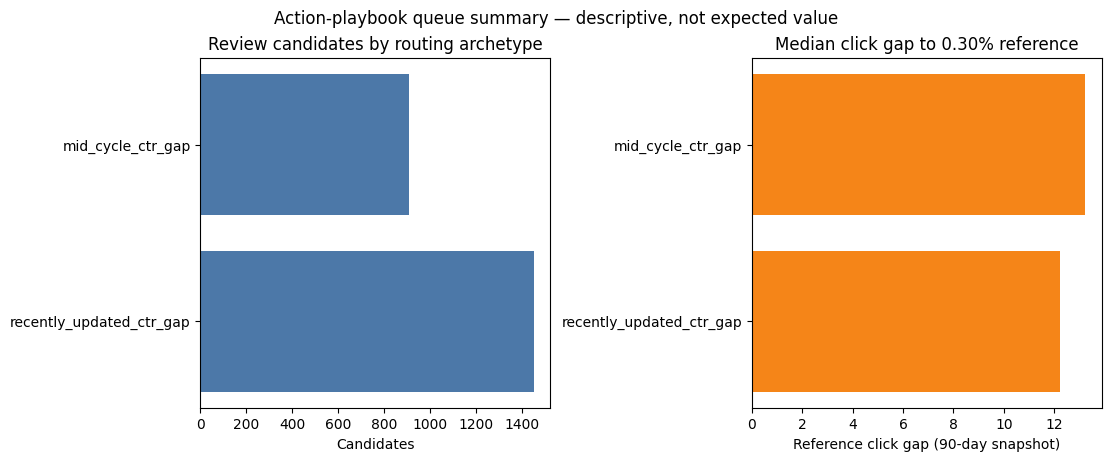

Wrote reusable figure to /content/flyrank-ml-internship-starter/flyrank-ml-internship-starter/flyrank-ml-internship-starter/work/figures/w07_action_playbook_queue_summary.png


In [6]:
display(refresh_summary.round({'median_reference_click_gap': 2}))
print('Observed freshness distribution is descriptive only: it establishes neither a decay curve nor a refresh effect.')
plot_data = archetype_summary.sort_values('median_reference_click_gap')
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
axes[0].barh(plot_data['archetype'], plot_data['candidates'], color='#4C78A8'); axes[0].set(title='Review candidates by routing archetype', xlabel='Candidates', ylabel='')
axes[1].barh(plot_data['archetype'], plot_data['median_reference_click_gap'], color='#F58518'); axes[1].set(title='Median click gap to 0.30% reference', xlabel='Reference click gap (90-day snapshot)', ylabel='')
fig.suptitle('Action-playbook queue summary — descriptive, not expected value')
FIGURE_PATH = FIGURE_DIR / 'w07_action_playbook_queue_summary.png'
fig.savefig(FIGURE_PATH, dpi=160, bbox_inches='tight'); plt.show()
print(f'Wrote reusable figure to {FIGURE_PATH.resolve()}')


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*


**Intended use:** once per review cycle, an SEO/content specialist pulls a capacity-limited batch, checks live context, and decides whether to decline, investigate, test, or scope work. It is an inspection list, not a system that decides which pages must change.

**Limits:** this is one anonymized trailing-90-day snapshot. The rule cannot separate title quality from query mix, SERP features, seasonality, tracking, brand demand, or competitor changes. The 0.30% reference is a screening threshold, not a target for every page. The dataset has no revenue, conversion, editorial-cost, or post-change outcomes, so the score cannot estimate ROI.

In [7]:
use_and_limits = pd.DataFrame([
 ['Use', 'Order a small human review batch where Page-1 visibility and low observed CTR create a potentially material inspection opportunity.'],
 ['Score unit', 'Click gap to a 0.30% reference in the observed 90-day window; not expected clicks, value, or ROI.'],
 ['Validation boundary', 'The prior audit found snapshot-label overlap risk; this playbook does not present the rule as a future-decline model.'],
 ['Causal boundary', 'No intervention or matched comparison was run, so no refresh effect is claimed.'],
 ['Portfolio boundary', 'This starter slice may not transfer to a different client, topic, season, or SERP environment.'],
], columns=['topic', 'honest statement'])
display(use_and_limits)
capacity = pd.DataFrame({'weekly_candidates': [10, 20, 40]})
capacity['triage_hours_at_20_minutes_each'] = (capacity['weekly_candidates'] * 20 / 60).round(1)
capacity['planning_note'] = 'Add separately estimated editorial, legal, design, and experiment time only after human triage.'
print('Cost/value planning scenario — not measured economics:'); display(capacity)
print('Prioritize a limited batch by exposure, then compare expected work and business importance during review. Do not convert the reference click gap into revenue without conversion and value evidence.')


,topic,honest statement
0,Use,Order a small human review batch where Page-1 ...
1,Score unit,Click gap to a 0.30% reference in the observed...
2,Validation boundary,The prior audit found snapshot-label overlap r...
3,Causal boundary,"No intervention or matched comparison was run,..."
4,Portfolio boundary,This starter slice may not transfer to a diffe...


Cost/value planning scenario — not measured economics:


,weekly_candidates,triage_hours_at_20_minutes_each,planning_note
0,10,3.3,"Add separately estimated editorial, legal, des..."
1,20,6.7,"Add separately estimated editorial, legal, des..."
2,40,13.3,"Add separately estimated editorial, legal, des..."


Prioritize a limited batch by exposure, then compare expected work and business importance during review. Do not convert the reference click gap into revenue without conversion and value evidence.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*


Every candidate needs a reviewer decision and brief rationale. When evidence is missing or the cause is ambiguous, the correct disposition is **hold/decline**, not an automatic refresh. Reviewers retain live-context evidence outside this public notebook under their organization’s access and privacy rules.

In [8]:
review_steps = pd.DataFrame([
 ['Current search context', 'Inspect representative current SERPs and query groups; check whether position and low CTR are expected for the result layout.'],
 ['Intent and page fit', 'Compare page promise, title/snippet, likely intent, and the live page; note cannibalization or duplicate coverage.'],
 ['Freshness and accuracy', 'For older pages, verify factual currency, policy/compliance needs, and whether a recent update is still settling.'],
 ['Business and delivery', 'Confirm page importance, change feasibility, and an owner who can measure an approved test.'],
 ['Decision record', 'Record approve / investigate / hold / decline, reviewer rationale, proposed scope, and observation window.'],
], columns=['required check', 'human reviewer evidence'])
display(review_steps)
no_go = pd.DataFrame([
 ['Auto-publish or auto-edit titles, snippets, or body copy', 'The rule has no causal evidence and cannot assess brand, accuracy, legal, or editorial quality.'],
 ['Auto-delete, redirect, consolidate, or change canonicals', 'High-impact technical/content decisions require site context beyond this signal.'],
 ['Auto-approve sensitive, regulated, safety, or legal changes', 'Specialist and policy review are required.'],
 ['Auto-assign monetary value or ROI', 'No conversion, revenue, cost, or incremental-outcome evidence exists here.'],
 ['Expose client performance, raw queries, or URLs', 'They are unnecessary for the paper-facing queue and must remain access-controlled.'],
 ['Treat a rank as a refresh command', 'A rank orders review effort only; a reviewer may decline every candidate.'],
], columns=['must not be automated', 'why'])
display(no_go)


,required check,human reviewer evidence
0,Current search context,Inspect representative current SERPs and query...
1,Intent and page fit,"Compare page promise, title/snippet, likely in..."
2,Freshness and accuracy,"For older pages, verify factual currency, poli..."
3,Business and delivery,"Confirm page importance, change feasibility, a..."
4,Decision record,"Record approve / investigate / hold / decline,..."


,must not be automated,why
0,"Auto-publish or auto-edit titles, snippets, or...",The rule has no causal evidence and cannot ass...
1,"Auto-delete, redirect, consolidate, or change ...",High-impact technical/content decisions requir...
2,"Auto-approve sensitive, regulated, safety, or ...",Specialist and policy review are required.
3,Auto-assign monetary value or ROI,"No conversion, revenue, cost, or incremental-o..."
4,"Expose client performance, raw queries, or URLs",They are unnecessary for the paper-facing queu...
5,Treat a rank as a refresh command,A rank orders review effort only; a reviewer m...


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*


One snapshot cannot show drift, so the receipt below is a reproducible baseline for later date-stamped runs. Compare queue volume, input validity, and archetype mix. Monitor the review workflow separately from model quality: reviewer acceptance or later traffic movement alone would not prove the rule worked because reviewers select which pages to change.

Any future retraining claim needs forward-looking labels with feature-as-of timestamps, time-aware and client-aware holdouts, and a comparison with this transparent rule. Do not retrain merely because a dashboard moved.

In [9]:
monitoring_plan = pd.DataFrame([
 ['Every run', 'Rows received; missing/invalid position, CTR, and impression fields; queue count; archetype/freshness mix.', 'Stop and investigate invalid or unexpectedly incomplete inputs.'],
 ['Each review cycle', 'Batch size, reviewer disposition, rationale, time spent, and whether a change/test was authorized.', 'If hold/decline reasons cluster, revise the review rubric before changing the score.'],
 ['Two comparable runs', 'Queue count or archetype share shifts 30%+ after checking tracking and seasonality.', 'Audit definitions and live SERP conditions; do not call it model drift automatically.'],
 ['Before retraining', 'Forward labels, feature timestamps, no label-window overlap, and time/client holdouts.', 'Compare a candidate model with this baseline; retain simpler route if held-out ranking does not improve.'],
 ['After approved tests', 'Pre-specified post-change measurement with an appropriate comparison where feasible.', 'Report observed outcomes and selection limits; do not attribute all change to a refresh.'],
], columns=['cadence', 'monitor', 'trigger / response'])
display(monitoring_plan)
input_checks = {'rows_loaded': int(len(df)), 'missing_impressions_90d': int(df['impressions_90d'].isna().sum()), 'invalid_avg_position_nonpositive': int(df['avg_position'].le(0).sum()), 'missing_ctr': int(df['ctr'].isna().sum())}
print('Baseline input checks (position zero means no position data and is excluded by the Page-1 rule):', input_checks)


,cadence,monitor,trigger / response
0,Every run,"Rows received; missing/invalid position, CTR, ...",Stop and investigate invalid or unexpectedly i...
1,Each review cycle,"Batch size, reviewer disposition, rationale, t...","If hold/decline reasons cluster, revise the re..."
2,Two comparable runs,Queue count or archetype share shifts 30%+ aft...,Audit definitions and live SERP conditions; do...
3,Before retraining,"Forward labels, feature timestamps, no label-w...",Compare a candidate model with this baseline; ...
4,After approved tests,Pre-specified post-change measurement with an ...,Report observed outcomes and selection limits;...


Baseline input checks (position zero means no position data and is excluded by the Page-1 rule): {'rows_loaded': 30000, 'missing_impressions_90d': 0, 'invalid_avg_position_nonpositive': 1205, 'missing_ctr': 0}


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*


The operational queue is regenerated under work/outputs/w07_ranked_action_queue.csv and intentionally remains untracked. The compact JSON receipt and identifier-free figure are committed evidence for the paper.

In [11]:
ROOT = Path('.')
QUEUE_PATH, METRICS_PATH = OUTPUT_DIR / 'w07_ranked_action_queue.csv', OUTPUT_DIR / 'w07_action_playbook_metrics.json'
ranked_queue.to_csv(QUEUE_PATH, index=False)
receipt = {
 'purpose': 'Human-reviewed Page-1/low-CTR inspection queue; not a prediction, refresh command, or ROI estimate.',
 'rows_scored': int(len(df)), 'eligible_candidates': int(len(ranked_queue)),
 'rule': {'min_impressions_90d': MIN_IMPRESSIONS, 'avg_position_range': [MIN_POSITION, MAX_POSITION], 'max_ctr_pct': CTR_REFERENCE_PCT, 'sort_score': 'impressions_90d * (0.30 - ctr) / 100 for eligible pages'},
 'archetypes': archetype_summary.to_dict(orient='records'), 'freshness_summary': refresh_summary.to_dict(orient='records'), 'input_checks': input_checks, 'human_review_required': True,
 'no_go': ['auto_publish_or_edit', 'auto_delete_or_redirect', 'auto_roi_estimate', 'rank_as_refresh_command'], 'figure': str(FIGURE_PATH.relative_to(ROOT).as_posix()),
}
METRICS_PATH.write_text(json.dumps(receipt, indent=2) + '\n', encoding='utf-8')
assert ranked_queue['priority_rank'].tolist() == list(range(1, len(ranked_queue) + 1))
assert set(ranked_queue.columns).isdisjoint({'client_id', 'trend_direction', 'trend_pct', 'is_declining_label'})
assert FIGURE_PATH.is_file() and METRICS_PATH.is_file() and QUEUE_PATH.is_file()
print(f'Wrote operational queue (untracked): {QUEUE_PATH.resolve()}')
print(f'Wrote committed paper receipt: {METRICS_PATH.resolve()}')
print(f'Wrote committed reusable figure: {FIGURE_PATH.resolve()}')

Wrote operational queue (untracked): /content/flyrank-ml-internship-starter/flyrank-ml-internship-starter/flyrank-ml-internship-starter/work/outputs/w07_ranked_action_queue.csv
Wrote committed paper receipt: /content/flyrank-ml-internship-starter/flyrank-ml-internship-starter/flyrank-ml-internship-starter/work/outputs/w07_action_playbook_metrics.json
Wrote committed reusable figure: /content/flyrank-ml-internship-starter/flyrank-ml-internship-starter/flyrank-ml-internship-starter/work/figures/w07_action_playbook_queue_summary.png


## Self-check

- [x] Ranked actions retain a transparent rule, explicit reason codes, and routing archetypes.
- [x] Intended use, score units, limits, and cost/value boundary are stated without causal or ROI claims.
- [x] Human-review evidence and a no-go list state what is not automated.
- [x] Monitoring distinguishes data/workflow checks from retraining evidence.
- [x] The operational queue, metrics receipt, and identifier-free figure are regenerated.
- [x] Executed this notebook top to bottom with no code-cell errors.

In [12]:
required_fields = {'reason_code', 'archetype', 'action_label', 'review_bundle'}
assert required_fields.issubset(ranked_queue.columns) and len(ranked_queue) > 0
print('SELF-CHECK PASS')
print(f'{len(ranked_queue):,} ranked review candidates; human review remains required for every action.')
print('No client names, URLs, raw queries, client IDs, or label-derived trend fields appear in the paper-facing queue.')


SELF-CHECK PASS
2,354 ranked review candidates; human review remains required for every action.
No client names, URLs, raw queries, client IDs, or label-derived trend fields appear in the paper-facing queue.
